In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print("Path to competition files:", path)

train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

train.drop(columns = "Id", axis = 1, inplace = True)
test.drop(columns = "Id", axis = 1, inplace = True)



/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv
Path to competition files: /kaggle/input/competitions/house-prices-advanced-regression-techniques


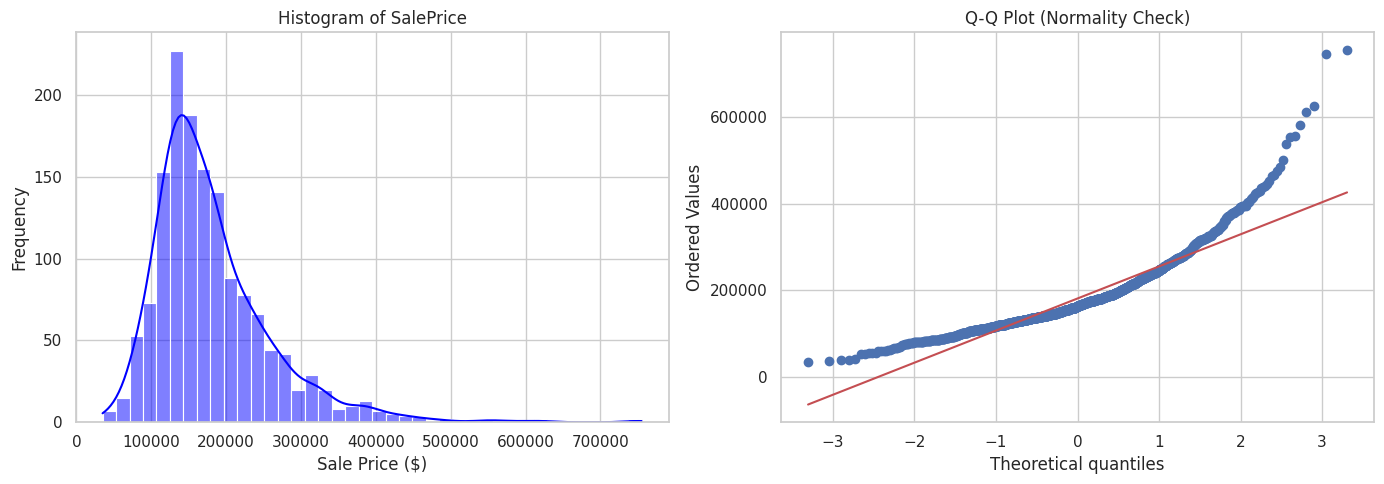

Total outliers detected: 60


In [2]:
# Data Analysis and processing
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, bins=40, color='blue')
plt.title('Histogram of SalePrice')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')


plt.subplot(1, 2, 2)
stats.probplot(train['SalePrice'], plot=plt)
plt.title('Q-Q Plot (Normality Check)')

# Display the charts
plt.tight_layout()
plt.show()

# removing outliers 
# Drop the specific extreme outliers recommended by the dataset creator
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

# check and mark for outliers using sklearn IsolationForest
from sklearn.ensemble import IsolationForest

numeric_data = train.select_dtypes(exclude=['object'])

isolation = IsolationForest()

outlier_labels = isolation.fit_predict(numeric_data)

# Count how many outliers were found
print(f"Total outliers detected: {(outlier_labels == -1).sum()}")

# View the outlier rows
outliers = numeric_data[outlier_labels == -1]

## Merge test and train data for preprocessing
data_merge = pd.concat([test.assign(ind = "test"),train.assign(ind = "train")])

## filling No_feature NaN objects
cols_with_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in cols_with_none:
    data_merge[col] = data_merge[col].fillna('None')

## filling 0 for NaN values

cols_with_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 
    'MasVnrArea'
]

for col in cols_with_zero:
    data_merge[col] = data_merge[col].fillna(0)

missing =[]

for col in data_merge.columns:
    if data_merge[col].isnull:
        missing.append(col)
        
categorical_cols=[cname for cname in data_merge.columns if data_merge[cname].dtypes=='object' and cname!='ind']
remaining_cat_cols = [cname for cname in categorical_cols if cname not in (cols_with_none + cols_with_zero)]
#Handling Missing Values in Categorical features by replacing them with the feature mode value
for col in remaining_cat_cols:
    data_merge[col] = data_merge[col].fillna(data_merge[col].mode()[0])

numeric_col = numeric_data.columns
data_merge[numeric_col] = data_merge[numeric_col].fillna(data_merge[numeric_col].mean())

#Select categorical columns with low cardinality
categorical_cols_less=[cname for cname in data_merge.columns if data_merge[cname].dtypes=='object' and data_merge[cname].nunique()<10]
numerical_col = [cname for cname in data_merge.columns if data_merge[cname].dtypes != "object"]


one_hot = data_merge[categorical_cols_less+numerical_col].copy()

In [3]:
## Feature Engineering
# calculating lasted years(how old)

one_hot['GarageYrBlt'] = one_hot['GarageYrBlt'].astype('int')

one_hot['GarageYrBlt'] = one_hot['YrSold'] - one_hot['GarageYrBlt']
one_hot['YearBuilt'] = one_hot['YrSold'] - one_hot['YearBuilt']
one_hot['YearRemodAdd'] = one_hot['YrSold'] - one_hot['YearRemodAdd']
one_hot.drop(columns = "YrSold", inplace=True)
one_hot.drop(columns = "MoSold", inplace=True)

# calculate the above ground and underground available square feet values

one_hot.drop(columns = "TotalBsmtSF", inplace=True)
#Basement finished area
one_hot['BsmtFinSF'] = one_hot['BsmtFinSF1'] + one_hot['BsmtFinSF2']
one_hot.drop(columns = "BsmtFinSF1" , inplace=True)
one_hot.drop(columns = "BsmtFinSF2", inplace=True)
#Total floor square feet
one_hot['TotalFlrSF'] = one_hot['1stFlrSF'] + one_hot['2ndFlrSF']

one_hot.drop(columns = "1stFlrSF", inplace=True)
one_hot.drop(columns = "2ndFlrSF", inplace=True)

## total_bathroom space
# Calculate the total bathrooms
one_hot['Total_Bath'] = (one_hot['FullBath'] 
        + (0.5 * one_hot['HalfBath']) 
        + one_hot['BsmtFullBath'] 
        + (0.5 * one_hot['BsmtHalfBath']))

# Drop the original columns line by line
one_hot.drop(columns="FullBath", inplace=True)
one_hot.drop(columns="HalfBath", inplace=True)
one_hot.drop(columns="BsmtFullBath", inplace=True)
one_hot.drop(columns="BsmtHalfBath", inplace=True)

In [4]:
## check for skewness and fix with log1p transform

num_cols = [cname for cname in one_hot.columns if one_hot[cname].dtypes != "object" and cname!='SalePrice']
skewness = one_hot[num_cols].skew().abs()
skewed_cols = skewness[skewness > 0.5].index
one_hot[skewed_cols] = one_hot[skewed_cols].clip(lower=0)
one_hot[skewed_cols] = np.log1p(one_hot[skewed_cols])

print(f"Fixed {len(skewed_cols)} skewed columns.")

# Mapping for quality features
quality_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}

#features indicating quality measures
cols_to_map = ['PoolQC', 'FireplaceQu', 'GarageQual', 'GarageCond', 
               'BsmtQual', 'BsmtCond', 'ExterQual', 'ExterCond', 
               'KitchenQual', 'HeatingQC']

for col in cols_to_map:
    # Fill missing values with 'None' first if you haven't already
   #one_hot[col] = one_hot[col].fillna('None') 
    one_hot[col] = one_hot[col].map(quality_mapping)

cols_to_one_hot = [cname for cname in one_hot.columns if one_hot[cname].dtype == 'object' and cname not in cols_to_map]



one_hot['BsmtExposure'] = one_hot['BsmtExposure'].map({"None":0,"No":1,"Mn":2,"Av":3,"Gd":4}).astype('int')
one_hot['BsmtFinType1'] = one_hot['BsmtFinType1'].map({"None":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
one_hot['BsmtFinType2'] = one_hot['BsmtFinType2'].map({"None":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
one_hot['GarageFinish'] = one_hot['GarageFinish'].map({"None":0,"Unf":1,"RFn":2,"Fin":3}).astype('int')
one_hot['Fence'] = one_hot['Fence'].map({"None":0,"MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4}).astype('int')

one_hot['LotShape'] = one_hot['LotShape'].map({"IR3":1,"IR2":2,"IR1":3,"Reg":4}).astype('int')
one_hot['LandContour'] = one_hot['LandContour'].map({"Low":1,"Bnk":2,"HLS":3,"Lvl":4}).astype('int')
one_hot['Utilities'] = one_hot['Utilities'].map({"ELO":1,"NoSeWa":2,"NoSewr":3,"AllPub":4}).astype('int')
one_hot['LandSlope'] = one_hot['LandSlope'].map({"Sev":1,"Mod":2,"Gtl":3}).astype('int')
one_hot['CentralAir'] = one_hot['CentralAir'].map({"N":0,"Y":1}).astype('int')
one_hot['PavedDrive'] = one_hot['PavedDrive'].map({"N":0,"P":1,"Y":2}).astype('int')

remaining = [cname for cname in one_hot.columns if one_hot[cname].dtype == 'object' and cname != 'ind']

one_hot_encoded = pd.get_dummies(one_hot[remaining])
one_hot.drop(columns = remaining, inplace = True)
final_cleaned = pd.concat([one_hot_encoded,one_hot],axis=1)
missing_counts = final_cleaned.isna().sum()
columns_with_nans = missing_counts[missing_counts > 0]




Fixed 22 skewed columns.


In [5]:
## The dataset has very large number of features, which can lead a normal regression model for overfitting
# Use a regularized regression model Lasso for linear regression model
# split the data back again

test, train= final_cleaned[final_cleaned["ind"] == ("test")], final_cleaned[final_cleaned["ind"] == ("train")]
test = test.drop(columns =  ["SalePrice", "ind"])
train = train.drop(columns = "ind")
target = np.log1p(train['SalePrice'])
train = train.drop(columns = 'SalePrice')


In [6]:
## Models 

# model 1 Lasso Model
# model 2 xgboost regressor
# model 3 catboost regressor
# combine 3 with stacking

from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import KFold


catboost_params = {
    'iterations': 5000,
    'learning_rate': 0.02,
    'depth': 4,
    'eval_metric':'RMSE',
    'verbose' : 0
}

xgboost_params = {
    'n_estimators': 5000,
    'learning_rate': 0.02,
    'colsample_bytree': 0.5,
    'subsample': 0.5,
    'min_child_weight': 2,


}

kf = KFold(n_splits=5 , shuffle=True, random_state= 42)


xgb_model = XGBRegressor(**xgboost_params, random_state=42)
xgb_model.fit(train, target)

# Train CatBoost on raw data
cat_model = CatBoostRegressor(**catboost_params, random_state=42)
cat_model.fit(train, target)

# Scale features for Lasso
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)
Lasso_model = Lasso(alpha=0.0005, max_iter=10000, random_state=42)
Lasso_model.fit(train_scaled,target)

# make the ensemble

# Get predictions from each model
pred_lasso = Lasso_model.predict(test_scaled)
pred_xgb = xgb_model.predict(test)
pred_cat = cat_model.predict(test)

# Blend them together (weights must add up to 1.0)
# Example: 20% Lasso, 40% XGBoost, 40% CatBoost
final = (0.2 * pred_lasso) + (0.4 * pred_xgb) + (0.4 * pred_cat)

print(final[:5])


[11.69186743 12.00080126 12.11426372 12.16070484 12.13414713]


In [ ]:
from sklearn.metrics import mean_squared_error

rmse_scores = []

# K fold cross validation 
for train_idx, val_idx in kf.split(train):
    # Split data into fold-specific train and validation sets
    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_tr, y_val = target.iloc[train_idx], target.iloc[val_idx]
    
    # 1. Train XGBoost
    xgb_model = XGBRegressor(**xgboost_params, random_state=42)
    xgb_model.fit(X_tr, y_tr)
    
    # 2. Train CatBoost
    cat_model = CatBoostRegressor(**catboost_params, random_state=42)
    cat_model.fit(X_tr, y_tr, verbose=False)
    
    # 3. Scale and Train Lasso
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    
    lasso_model = Lasso(alpha=0.0005, max_iter=10000, random_state=42)
    lasso_model.fit(X_tr_scaled, y_tr)
    
    # 4. Predict on validation fold and blend
    p_lasso = lasso_model.predict(X_val_scaled)
    p_xgb = xgb_model.predict(X_val)
    p_cat = cat_model.predict(X_val)
    
    val_blend = (0.2 * p_lasso) + (0.4 * p_xgb) + (0.4 * p_cat)
    
    # Calculate RMSE for this fold (often log-transformed in Ames, but using RMSE here as an example)
    rmse = np.sqrt(mean_squared_error(y_val, val_blend))
    rmse_scores.append(rmse)

print(f"Cross-Validation RMSE scores across folds: {rmse_scores}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")



'from sklearn.metrics import mean_squared_error\n\nrmse_scores = []\n\n# K fold cross validation \nfor train_idx, val_idx in kf.split(train):\n    # Split data into fold-specific train and validation sets\n    X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]\n    y_tr, y_val = target.iloc[train_idx], target.iloc[val_idx]\n    \n    # 1. Train XGBoost\n    xgb_model = XGBRegressor(**xgboost_params, random_state=42)\n    xgb_model.fit(X_tr, y_tr)\n    \n    # 2. Train CatBoost\n    cat_model = CatBoostRegressor(**catboost_params, random_state=42)\n    cat_model.fit(X_tr, y_tr, verbose=False)\n    \n    # 3. Scale and Train Lasso\n    scaler = StandardScaler()\n    X_tr_scaled = scaler.fit_transform(X_tr)\n    X_val_scaled = scaler.transform(X_val)\n    \n    lasso_model = Lasso(alpha=0.0005, max_iter=10000, random_state=42)\n    lasso_model.fit(X_tr_scaled, y_tr)\n    \n    # 4. Predict on validation fold and blend\n    p_lasso = lasso_model.predict(X_val_scaled)\n    p_xgb = xgb

In [8]:
final_predictions = np.expm1(final)
output = pd.DataFrame({'Id': test.index+1461,
                       'SalePrice': final_predictions})
output.to_csv('submission.csv', index=False)